# Predicting High-Risk Urban Zones in Lagos Using Machine Learning for Smart City Planning

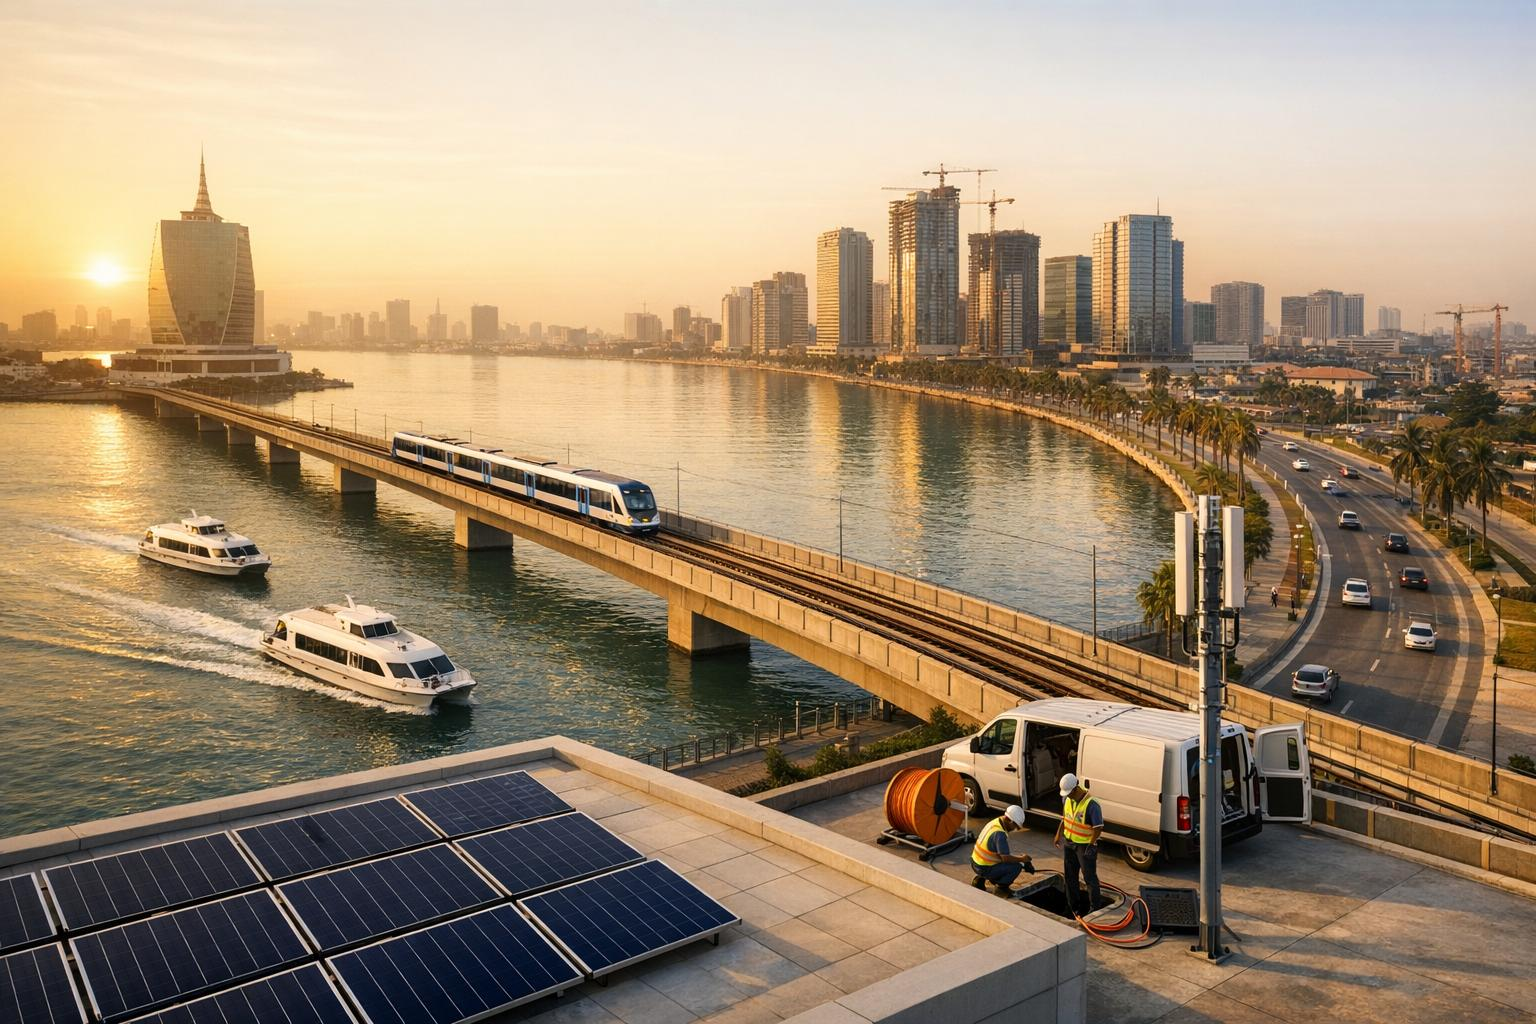

#### TABLE OF CONTENT

#### 1. INTRODUCTION
    1.0 OVERVIEW
    1.1 AIM
    1.2 DATASET COLUMNS EXPLANATION

#### 2. REPOSITORY
    2.0 IMPORT LIBRARIES
    2.1 LOAD DATASET


#### 3. EXPLORATORY DATA ANALYSIS 
    3.0 UNDERSTAND THE DATA
    3.1 CHECK FOR DUPLICATES
    3.2 CHECK FOR MISSING VALUES
    3.4 VISUALIZE RELATIONSHIPS AND DISTRIBUTIONS
    

#### 4. MODEL DEVELOPMENT
    4.0 SPLI DATA
    4.1 MODEL TRAINING
    4.2 MODEL EVALUATION
    4.3 CROSS VALIDATION
    4.4 FEATURE IMPORTANCE
    4.5 PREDICT ENTIRE DATASET

#### 5. MAP CREATION
    5.0 SMART CITY RISK MAP CREATION

#### 6. SUMMARY OF FINDINGS
    6.0 SUMMARY

#### 1. INTRODUCTION

    1.0 OVERVIEW
    

Urban zones in Lagos are characterized by rapid population growth, increasing infrastructure pressure, and varying levels of environmental and public safety risks. These challenges make it important to identify areas that may be more vulnerable to issues such as traffic congestion, poor drainage, and limited emergency response access.

This project focuses on applying a simple machine learning approach to predict whether an area in Lagos can be classified as high risk or low risk based on key urban indicators. These indicators include traffic density, road condition, rainfall level, drainage quality, population density, street lighting, and emergency response access.

Using these features, a classification model was developed to identify patterns associated with higher-risk urban zones. The results are further visualized on a map to demonstrate how data-driven insights can support smarter urban planning and decision-making.

For the purpose of this prototype, a synthetically generated dataset was used to simulate realistic urban conditions across selected areas in Lagos. This allows for the demonstration of the modeling approach while highlighting its potential application to real-world smart city systems.

    1.1 AIM
    

This project aims to develop a simple machine learning model to predict high-risk urban zones across selected parts of Lagos using key urban and environmental indicators, and to visualize these insights as a prototype to support data-driven smart city planning.

    1.2 DATASET COLUMNS EXPLANATION

* area - location name
* latitude, longitude - for mapping
* traffic_density - scale from 1 to 10
* road_condition - scale from 1 to 10, where higher means better road
* rainfall_level - scale from 1 to 10
* drainage_quality - scale from 1 to 10, where higher means better drainage
* population_density - scale from 1 to 10
* street_lighting - scale from 1 to 10, where higher means better lighting
* emergency_access - scale from 1 to 10, where higher means easier access
* risk_level - target column: 1 means high risk, 0 means low risk

#### 2. REPOSITORY

    2.0 IMPORT LIBARIES

Importing libraries is a critical step before loading the dataset. It is critical to import only the libraries that you are certain you will need to work with your dataset. To import to libraries, use the keyword "import".

In [1]:
# import all necessary libraries

import pandas as pd
import numpy as np
import folium
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

    2.1 LOAD DATASET

In [2]:
# Load dataset
urbandata = pd.read_csv(r"C:\Users\User\Documents\Tech\InteRussia\Project\urban data.csv")

In [3]:
# Show the data
urbandata

,area,latitude,longitude,traffic_density,road_condition,rainfall_level,drainage_quality,population_density,street_lighting,emergency_access,risk_level
0,Ojota,6.5786,3.3869,9,4,8,3,9,4,5,1
1,Yaba,6.5095,3.3711,8,6,6,5,8,6,7,0
2,Lekki,6.4698,3.5852,7,8,5,7,7,8,8,0
3,Ikorodu,6.6194,3.5105,8,5,7,4,8,5,5,1
4,Ajegunle,6.4561,3.3596,9,3,7,3,9,3,4,1
5,Surulere,6.4969,3.3615,7,6,6,5,7,6,6,0
6,Ikeja,6.6018,3.3515,6,7,5,6,7,7,8,0
7,Agege,6.6156,3.3209,8,4,7,4,9,4,5,1
8,Badagry,6.4150,2.8833,4,6,5,6,5,5,5,0
9,Victoria Island,6.4281,3.4219,6,8,5,7,6,8,8,0


The above gives all the records / observations in the dataset.

#### 3. EXPLORATORY DATA ANALYSIS

This examines the structure and quality of the training dataset. It involves reviewing the dataset to understand its features, identifying duplicate and missing records, and using basic visualizations to observe patterns and distributions that inform later preprocessing and modeling decisions.

    3.0 UNDERSTAND THE DATA

In [4]:
# Check for the no. of rows and columns dataframe
urbandata.shape

(20, 11)

The dataframe has 20 rows and 11 columns.

In [5]:
# List out the column titles in the dataframe
urbandata.columns

Index(['area', 'latitude', 'longitude', 'traffic_density', 'road_condition',
       'rainfall_level', 'drainage_quality', 'population_density',
       'street_lighting', 'emergency_access', 'risk_level'],
      dtype='object')

The above shows all the columns in the dataframe

In [6]:
#Check the data types available in each column
urbandata.dtypes

area                   object
latitude              float64
longitude             float64
traffic_density         int64
road_condition          int64
rainfall_level          int64
drainage_quality        int64
population_density      int64
street_lighting         int64
emergency_access        int64
risk_level              int64
dtype: object

The above shows the data types for each column

In [7]:
# Check for the unique values in each column
urbandata.nunique()

area                  20
latitude              20
longitude             20
traffic_density        7
road_condition         6
rainfall_level         5
drainage_quality       6
population_density     6
street_lighting        7
emergency_access       6
risk_level             2
dtype: int64

The analysis shows the total no. of unique values in each column of the dataframe.

In [8]:
#check for unique values with their count in a column
urbandata["traffic_density"].value_counts()

traffic_density
8     5
9     4
7     3
6     3
5     3
4     1
10    1
Name: count, dtype: int64

The analysIs show the unique values and respective counts in the "traffic_density" column for the dataframe.




In [9]:
#show the dataframe info
urbandata.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   area                20 non-null     object 
 1   latitude            20 non-null     float64
 2   longitude           20 non-null     float64
 3   traffic_density     20 non-null     int64  
 4   road_condition      20 non-null     int64  
 5   rainfall_level      20 non-null     int64  
 6   drainage_quality    20 non-null     int64  
 7   population_density  20 non-null     int64  
 8   street_lighting     20 non-null     int64  
 9   emergency_access    20 non-null     int64  
 10  risk_level          20 non-null     int64  
dtypes: float64(2), int64(8), object(1)
memory usage: 1.8+ KB


This provides basic information about the dataframe. It contains categorical values, which are represented by columns with 'object' data types, numerical values, which are represented by columns with 'float64 and int64' data types, and boolean values which are represented by columns with 'bool' data types.

In [10]:
# Check for the descriptions of the numerical and categorical columns of the data
urbandata.describe(include='all')

,area,latitude,longitude,traffic_density,road_condition,rainfall_level,drainage_quality,population_density,street_lighting,emergency_access,risk_level
count,20,20.000000,20.000000,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
unique,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Ojota,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,6.532360,3.387110,7.20000,5.500000,6.100000,4.900000,7.450000,5.450000,5.950000,0.450000
std,NaN,0.072905,0.191775,1.67332,1.732051,1.020836,1.518309,1.503505,1.820208,1.571958,0.510418
min,NaN,6.415000,2.883300,4.00000,3.000000,4.000000,3.000000,5.000000,3.000000,4.000000,0.000000
25%,NaN,6.466300,3.348125,6.00000,4.000000,5.000000,4.000000,6.750000,4.000000,5.000000,0.000000
50%,NaN,6.540700,3.366300,7.50000,6.000000,6.000000,5.000000,7.500000,5.000000,5.000000,0.000000
75%,NaN,6.597825,3.398575,8.25000,6.250000,7.000000,6.000000,9.000000,6.250000,7.250000,1.000000


It provides a summary of various statistical measures for all columns. Numerical columns include measures such as mean, standard deviation, minimum, maximum, and quartiles, while categorical columns include count, number of unique values, most frequent value, and its frequency.

In [11]:
# Check for specific row using data slicing; in this case the 16th row
urbandata.loc[15]

area                  Magodo
latitude              6.6412
longitude              3.385
traffic_density            5
road_condition             8
rainfall_level             5
drainage_quality           7
population_density         6
street_lighting            8
emergency_access           8
risk_level                 0
Name: 15, dtype: object

The above fetches the data in the 16th row of the DataFrame.

In [12]:
# Retrieve data from the 12th row to 17th row
urbandata.loc[11:16]

,area,latitude,longitude,traffic_density,road_condition,rainfall_level,drainage_quality,population_density,street_lighting,emergency_access,risk_level
11,Epe,6.5841,3.9836,5,6,6,5,5,5,5,0
12,Maryland,6.5708,3.3731,7,6,6,5,7,6,7,0
13,Apapa,6.4488,3.3590,9,4,6,4,8,4,5,1
14,Oshodi,6.5536,3.3431,10,3,7,3,10,3,4,1
15,Magodo,6.6412,3.3850,5,8,5,7,6,8,8,0
16,Ikoyi,6.4549,3.4306,5,8,4,8,5,9,9,0


The above fetches the data for rows 12 through 17 (assuming a zero-based index) of the DataFrame

        3.1 CHECK FOR DUPLICATES

In [13]:
# check for duplicated values for each row
urbandata[urbandata.duplicated(keep=False)]


,area,latitude,longitude,traffic_density,road_condition,rainfall_level,drainage_quality,population_density,street_lighting,emergency_access,risk_level


The above shows there is no occurence of duplicates in the dataframe.

    3.2 CHECK FOR MISSING VALUES

In [14]:
# Check for possibility of null values in each column
urbandata.isnull().any()

area                  False
latitude              False
longitude             False
traffic_density       False
road_condition        False
rainfall_level        False
drainage_quality      False
population_density    False
street_lighting       False
emergency_access      False
risk_level            False
dtype: bool

In [15]:
# Show the amount of missing values in each column (if any)
urbandata.isnull().sum()

area                  0
latitude              0
longitude             0
traffic_density       0
road_condition        0
rainfall_level        0
drainage_quality      0
population_density    0
street_lighting       0
emergency_access      0
risk_level            0
dtype: int64

All columns are false, and contain zero misisng values.

    3.3 VISUALIZE RELATIONSHIPS AND DISTRIBUTIONS

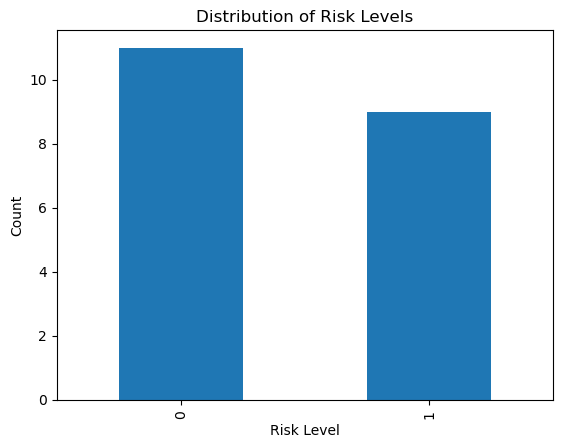

In [16]:
# Check Risk level distribution

# Create plot
urbandata["risk_level"].value_counts().plot(kind="bar")
plt.title("Distribution of Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Count")

# Show plot
plt.show()

This shows the distribution o risk levels

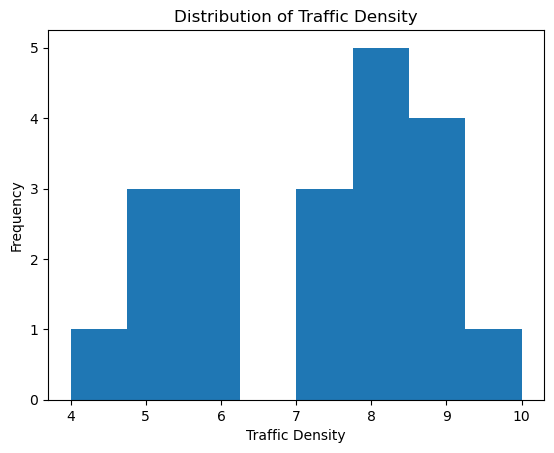

In [17]:
# Check for distribution of traffic density

# Create plot
urbandata["traffic_density"].plot(kind="hist", bins=8)
plt.title("Distribution of Traffic Density")
plt.xlabel("Traffic Density")
plt.ylabel("Frequency")

# Show plot
plt.show()

The histogram shows that traffic density values are concentrated in two separate ranges, roughly 4-6 and 7-10, with a visible gap between 6 and 7. This means the dataset contains two clusters of traffic density values rather than a continuous spread across the full range.

A larger share of the observations falls in the higher range, suggesting that relatively high traffic density is more common in the dataset than lower traffic density values.

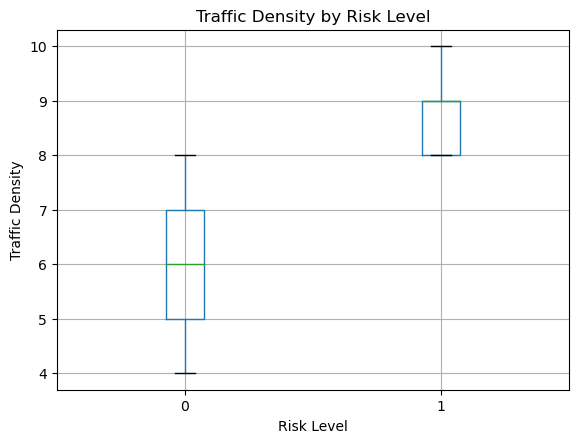

In [18]:
# Check the traffic density by risk level

# Create plot
urbandata.boxplot(column="traffic_density", by="risk_level")
plt.title("Traffic Density by Risk Level")
plt.suptitle("")
plt.xlabel("Risk Level")
plt.ylabel("Traffic Density")

# Show plot
plt.show()

The boxplot shows a clear difference in traffic density between low-risk and high-risk areas. High-risk areas (Risk Level 1) consistently exhibit higher traffic density values, generally ranging between 8 and 10, while low-risk areas (Risk Level 0) fall within a lower range of approximately 4 to 8.

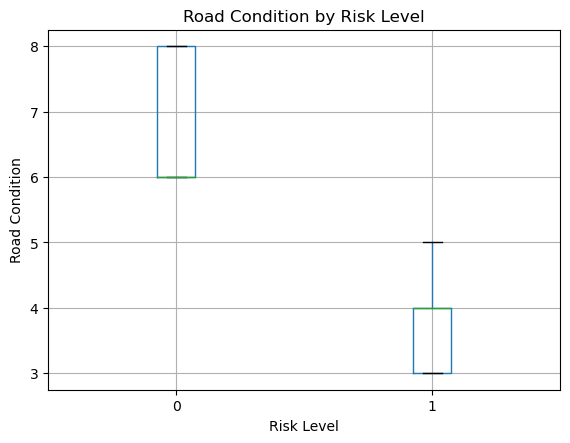

In [19]:
# Check road condition by risk level

# Create plot
urbandata.boxplot(column="road_condition", by="risk_level")
plt.title("Road Condition by Risk Level")
plt.suptitle("")
plt.xlabel("Risk Level")
plt.ylabel("Road Condition")

# Ahow plot
plt.show()

The boxplot reveals a clear separation between low-risk and high-risk areas based on road condition. Low-risk areas are associated with higher road condition values (6-8), while high-risk areas are concentrated within lower values (3-5), with no visible overlap between the two groups. This indicates that poor road condition is strongly associated with increased urban risk and is a significant predictor in the model.

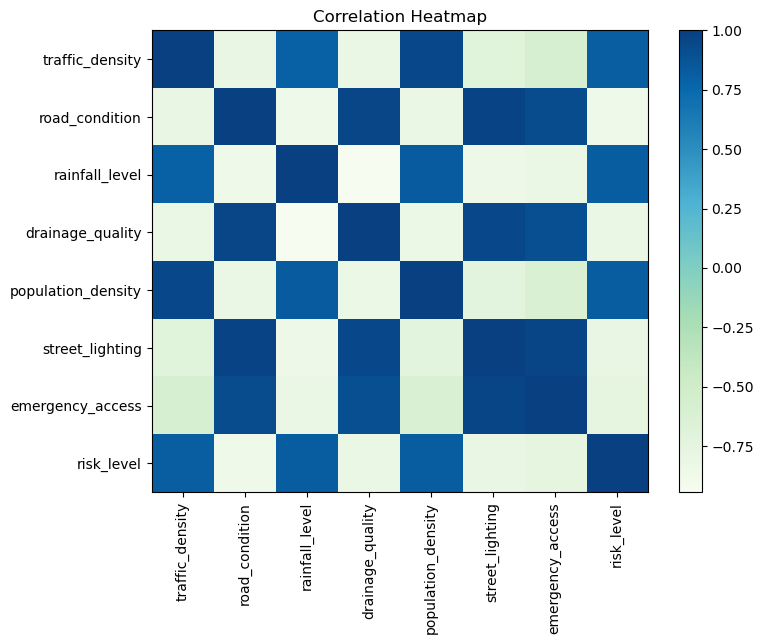

In [20]:
# Correlation Heatmap

# Create plot
corr = urbandata[[
    "traffic_density",
    "road_condition",
    "rainfall_level",
    "drainage_quality",
    "population_density",
    "street_lighting",
    "emergency_access",
    "risk_level"
]].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, aspect="auto", cmap="GnBu")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")

# Show plot
plt.show()




* +1 (dark blue) - strong positive relationship
* 0 (greenish/light) - weak or no relationship
* -1 (light/very pale) - strong negative relationship

The correlation heatmap shows that urban risk is positively associated with factors such as traffic density, population density, and rainfall level, while it is negatively associated with infrastructure-related variables including road condition, drainage quality, street lighting, and emergency access. This indicates that areas with higher congestion and environmental pressure, combined with weaker infrastructure, are more likely to be classified as high-risk zones.

In [21]:
# Check average feature by risk level

# Select features
features = [
    "traffic_density",
    "road_condition",
    "rainfall_level",
    "drainage_quality",
    "population_density",
    "street_lighting",
    "emergency_access"
]

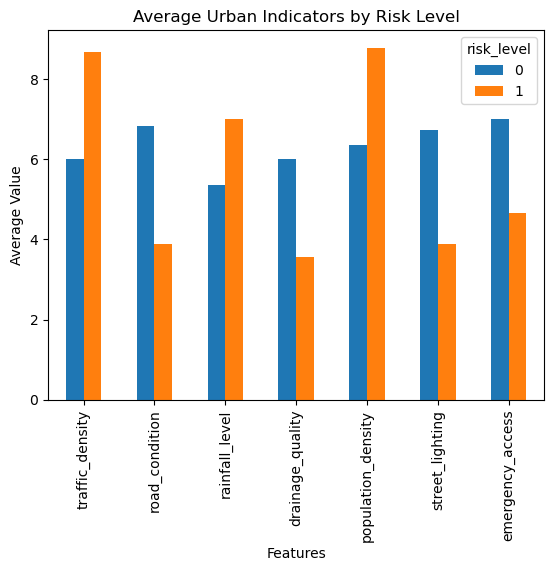

In [22]:
# Create plot
grouped = urbandata.groupby("risk_level")[features].mean().T
grouped.plot(kind="bar")
plt.title("Average Urban Indicators by Risk Level")
plt.xlabel("Features")
plt.ylabel("Average Value")

# Show plot
plt.show()

The grouped bar chart highlights a clear contrast between high-risk and low-risk areas. High-risk zones exhibit higher values in traffic density, population density, and rainfall level, indicating increased urban and environmental pressure. In contrast, infrastructure-related variables such as road condition, drainage quality, street lighting, and emergency access are lower in high-risk areas. This suggests that urban risk is driven by a combination of high demand pressures and insufficient infrastructure capacity.

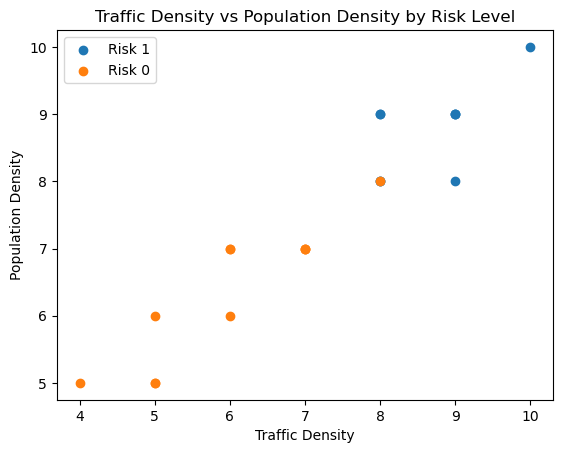

In [23]:
# Check Traffic density level vs Population density by risk level

# Create plot
for risk in urbandata["risk_level"].unique():
    subset = urbandata[urbandata["risk_level"] == risk]
    plt.scatter(subset["traffic_density"], subset["population_density"], label=f"Risk {risk}")

plt.title("Traffic Density vs Population Density by Risk Level")
plt.xlabel("Traffic Density")
plt.ylabel("Population Density")
plt.legend()

# Show plot
plt.show()

The scatter plot reveals a clear clustering pattern, where high-risk areas are concentrated in regions with both high traffic density and high population density, while low-risk areas are associated with lower values of these variables. This suggests that the combined effect of congestion and population pressure plays a significant role in determining urban risk levels.

#### 4. MODEL DEVELOPMENT

    4.0 SPLIT DATASET

In [24]:
# Select target
X = urbandata[features]
y = urbandata["risk_level"]

In [25]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

    4.1 MODEL TRAINING

    RANDOM FOREST MODEL

In [26]:
# Build the random forest model 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


Random forest model is trained using the train data

In [27]:
# Make predictions
y_pred = rf_model.predict(X_test)

    4.2 MODEL EVALUATION

In [28]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [30]:
print(confusion_matrix(y_test, y_pred))

[[4 0]
 [0 2]]


    4.3 CROSS VALIDATION

In [31]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Average CV score:", scores.mean())

Cross-validation scores: [1. 1. 1. 1. 1.]
Average CV score: 1.0


The Random Forest model achieved perfect performance on both the hold-out test set and 5-fold cross-validation, with an average cross-validation score of 1.00. This indicates that the selected features clearly separate the two risk classes in the prototype dataset. However, this result should be interpreted with caution, as the dataset is synthetic and relatively small, making the classification problem highly structured and easier than a real-world urban risk prediction task.

     4.4 FEATURE IMPORTANCE

In [32]:
importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print(importance)

road_condition        0.236412
traffic_density       0.210000
population_density    0.172800
drainage_quality      0.140000
street_lighting       0.127407
emergency_access      0.067756
rainfall_level        0.045625
dtype: float64


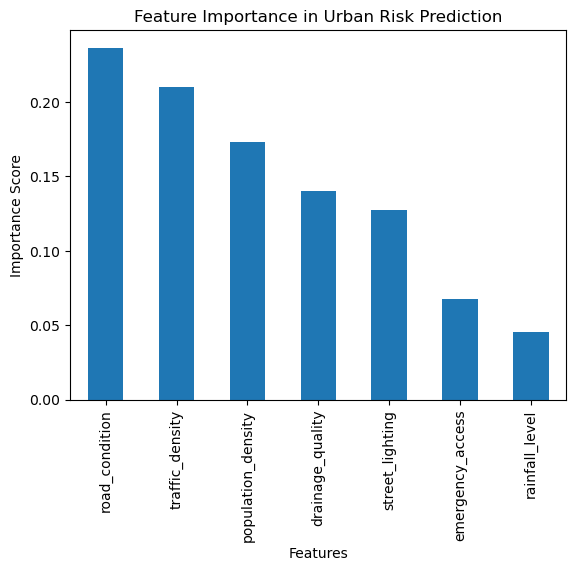

In [33]:
# Create plot
importance.plot(kind="bar")
plt.title("Feature Importance in Urban Risk Prediction")
plt.xlabel("Features")
plt.ylabel("Importance Score")

# Display plot
plt.show()

This shows which factors influenced the model more.

    4.5 PREDICT ENTIRE DATASET

In [34]:
urbandata["predicted_risk"] = rf_model.predict(X)
urbandata[["area", "predicted_risk"]].head()

,area,predicted_risk
0,Ojota,1
1,Yaba,0
2,Lekki,0
3,Ikorodu,1
4,Ajegunle,1


In [35]:
# Create text labels
urbandata["risk_label"] = urbandata["predicted_risk"].map({1: "High Risk", 0: "Low Risk"})

In [36]:
# Create probability score

urbandata["risk_probability"] = rf_model.predict_proba(X)[:, 1]
urbandata[["area", "risk_probability"]].head()

,area,risk_probability
0,Ojota,1.00
1,Yaba,0.40
2,Lekki,0.00
3,Ikorodu,0.96
4,Ajegunle,1.00


In [37]:
urbandata["risk_label"] = urbandata["risk_probability"].apply(
    lambda x: "High Risk" if x >= 0.5 else "Low Risk"
)

#### 5. RISK MAP

    5.0 SMART CITY RISK MAP CREATION

In [38]:
lagos_map = folium.Map(location=[6.5244, 3.3792], zoom_start=10)

In [39]:
for _, row in urbandata.iterrows():
    color = "red" if row["predicted_risk"] == 1 else "green"
    
    popup_text = f"""
    <b>Area:</b> {row['area']}<br>
    <b>Predicted Risk:</b> {row['risk_label']}<br>
    <b>Risk Probability:</b> {round(row['risk_probability'], 2)}<br>
    <b>Traffic Density:</b> {row['traffic_density']}<br>
    <b>Road Condition:</b> {row['road_condition']}<br>
    <b>Rainfall Level:</b> {row['rainfall_level']}<br>
    <b>Drainage Quality:</b> {row['drainage_quality']}<br>
    <b>Population Density:</b> {row['population_density']}<br>
    <b>Street Lighting:</b> {row['street_lighting']}<br>
    <b>Emergency Access:</b> {row['emergency_access']}
    """
    
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        popup=folium.Popup(popup_text, max_width=300),
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7
    ).add_to(lagos_map)

In [40]:
lagos_map.save("lagos_risk_map.html")

In [41]:
lagos_map

#### 6. SUMMARY OF FINDINGS

    6.0 SUMMARY

This project explored the use of machine learning and geospatial visualization to identify high-risk urban zones in Lagos based on selected environmental and infrastructure indicators.

The exploratory data analysis revealed clear patterns in the dataset. High-risk areas were generally associated with higher traffic density, population density, and rainfall levels, indicating increased urban pressure. In contrast, infrastructure-related variables such as road condition, drainage quality, street lighting, and emergency access were lower in high-risk areas, suggesting that poor infrastructure contributes significantly to urban vulnerability.

A Random Forest model was trained to classify areas into high-risk and low-risk categories. The model achieved perfect performance on both the test set and cross-validation. While this indicates strong separability within the dataset, the results are influenced by the synthetic and structured nature of the data, and therefore represent a proof-of-concept rather than a fully generalizable model.

Finally, an interactive geospatial map was developed using Folium to visualize predicted risk levels across Lagos. The map provides an intuitive way to explore spatial patterns and highlights areas that may require attention in terms of urban planning and infrastructure improvement.

The project demonstrates how data-driven approaches can support smart city planning by identifying areas of potential risk and guiding resource allocation.

This study shows that urban risk is influenced by a combination of high demand pressures and inadequate infrastructure. Future work could involve applying this approach to real-world datasets, incorporating additional variables, and improving model robustness for practical deployment.